In [8]:
import pandas as pd

url = "https://www.sharkattackfile.net/spreadsheets/GSAF5.xls"

df = pd.read_excel(url)

df = df.drop(columns= ["Time", "Unnamed: 21", "Unnamed: 22", "Name", "href", "Case Number", "Case Number.1", "original order", "href formula", "pdf", "Source", "Species ", "Injury", "Sex"])

percentage_missing = (df.isnull().sum() / len(df) * 100).round(2)

df.drop_duplicates(inplace=True)

df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())

df["Fatal Y/N"] = df["Fatal Y/N"].str.strip().str.upper().copy()

df["Fatal Y/N"] = df["Fatal Y/N"].replace({"Y X 2":"Y"}).copy()

df = df[df["Fatal Y/N"].isin(["Y", "N"])].copy()

df

,Date,Year,Type,Country,State,Location,Activity,Age,Fatal Y/N
0,18th March,2026.0,Unprovoked,USA,California,Big River Beach Mendocino County,Surfing,39,N
1,14th March,2026.0,Unprovoked,Australia,Western Australia,Exmouth,Swimming,?,N
2,10th March,2026.0,Unprovoked,Australia,Western Australia,Exmouth,Wing Foiling,?,N
3,5th March,2026.0,Unprovoked,Australia,Queensland,Lady Elliott Island,Snorkeling,50's,N
4,22nd February,2026.0,Unprovoked,New Caledonia,Noumea,Anse Vata near Point Magnin,Wing Foiling,55,Y
...,...,...,...,...,...,...,...,...,...
7077,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,Roebuck Bay,Diving,NaN,Y
7078,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,NaN,Pearl diving,NaN,Y
7079,1900-1905,0.0,Unprovoked,USA,North Carolina,Ocracoke Inlet,Swimming,NaN,Y
7080,1883-1889,0.0,Unprovoked,PANAMA,NaN,"Panama Bay 8ºN, 79ºW",NaN,NaN,Y


In [ ]:
h3_df = df[["Age", "Fatal Y/N"]].copy()


h3_df["Age"] = pd.to_numeric(h3_df["Age"], errors="coerce")


h3_df = h3_df.dropna(subset=["Age"])


h3_df["Age Group"] = pd.cut(
    h3_df["Age"],
    bins=[0, 10, 20, 30, 40, 50, 60, 100],
    labels=["0-9", "10-19", "20-29", "30-39", "40-49", "50-59", "60+"],
    right=False,
)


h3_df["Age Group"].value_counts()


Age Group
10-19    1159
20-29    1039
30-39     577
40-49     386
50-59     249
60+       144
0-9       128
Name: count, dtype: int64

In [51]:
h3_df["Is_Fatal"] = (h3_df["Fatal Y/N"] == "Y").astype(int)

summary_h3 = (h3_df.groupby("Age Group").agg(total_incidents=("Is_Fatal", "size"), fatal_incidents=("Is_Fatal" , sum))).copy()

summary_h3["fatality_rate (%)"] = ((summary_h3["fatal_incidents"] / summary_h3["total_incidents"]) * 100).round(1)

summary_h3


/var/folders/5r/56m82rjn5cqdmz3b771c5t8c0000gn/T/ipykernel_62026/4175566473.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_h3 = (h3_df.groupby("Age Group").agg(total_incidents=("Is_Fatal", "size"), fatal_incidents=("Is_Fatal" , sum))).copy()
/var/folders/5r/56m82rjn5cqdmz3b771c5t8c0000gn/T/ipykernel_62026/4175566473.py:3: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  summary_h3 = (h3_df.groupby("Age Group").agg(total_incidents=("Is_Fatal", "size"), fatal_incidents=("Is_Fatal" , sum))).copy()


,total_incidents,fatal_incidents,fatality_rate (%)
Age Group,,,
0-9,128,16,12.5
10-19,1159,209,18.0
20-29,1039,208,20.0
30-39,577,106,18.4
40-49,386,60,15.5
50-59,249,52,20.9
60+,144,34,23.6


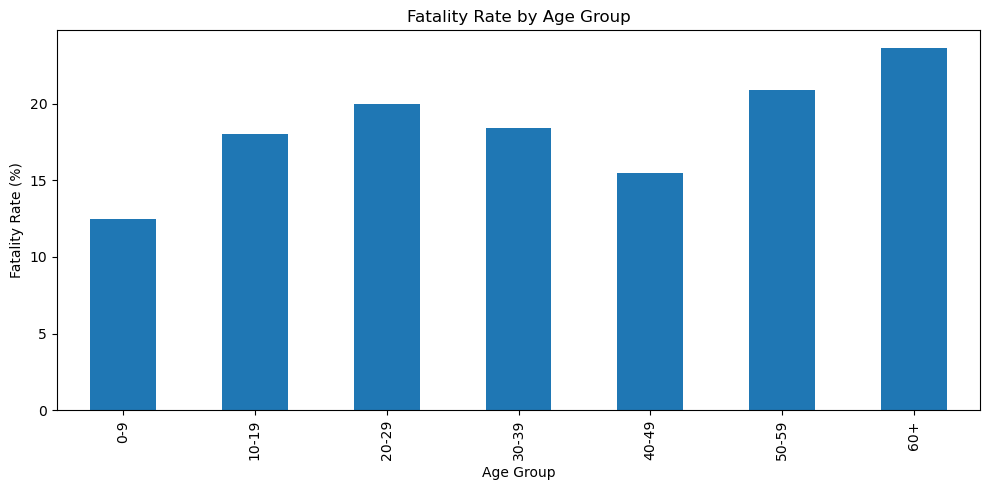

In [54]:
import matplotlib.pyplot as plt

summary_h3["fatality_rate (%)"].plot(kind="bar", figsize=(10, 5), title="Fatality Rate by Age Group", ylabel= "Fatality Rate (%)")

plt.tight_layout()

plt.show()

**H3 — Fatality rate by age**

**Findings:**

Fatality rate is not a smooth climb with age. The shape is more like a step function.

Children (0-9) have the lowest fatality rate, probably because kids are watched closely, stay close to shore, and get immediate help.
The clear jump happens at 50+, with 60+ being the highest-risk group by a noticeable margin.


**Conclusions:**

H3 is partially supported. Fatality rate does rise with age, but only past 50. It's not a smooth gradient across all ages.
The driver for older victims is likely survivability, not attack frequency — older people are less able to survive severe injuries due to slower healing, comorbidities, and slower response capability in the water.



**Recommendations for insurers:**

- Apply age loadings starting at 50, not across all ages. Below 50, fatality rates are essentially flat.
- Use a meaningful premium step at 60+ where the rate is highest.
- Consider the 0-9 group for reduced premiums or a "family policy" discount — they're the lowest-risk group in the dataset.
- Frame older-age pricing around severity, not frequency. Older victims aren't more likely to be attacked; they're more likely to die if attacked.
- Combine with H2 findings: an older traveler going to a high-severity country (Papua New Guinea, Hong Kong) is the highest-risk segment in the whole dataset. That combination deserves the most scrutiny.


**Caveats:**

- The 60+ bucket lumps 60s, 70s, and 80s together (because 70s and 80s had too few rows to stand alone). 
- 2,727 rows had missing ages and were dropped. If age is more likely to be missing for certain kinds of incidents (e.g., older records, specific regions), the remaining sample could be biased.